In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

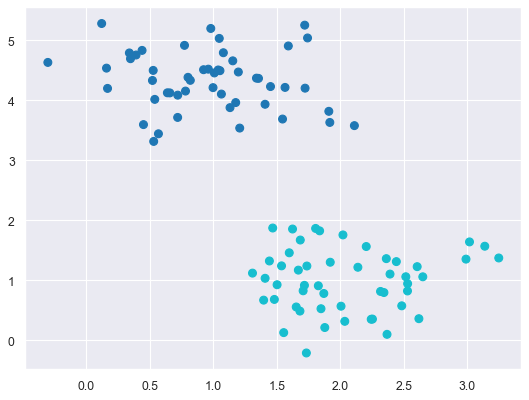

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.50)

plt.figure(figsize=(8, 6), dpi=80)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='tab10');

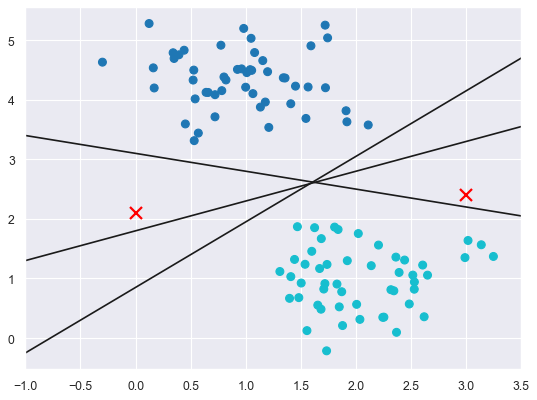

In [3]:
xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(8, 6), dpi=80)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='tab10')
plt.plot([0.0], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)
plt.plot([3.0], [2.4], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1.1, 0.85), (0.5, 1.8), (-0.3, 3.1)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

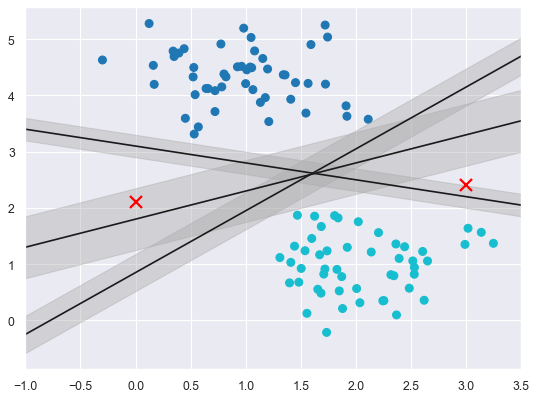

In [4]:
xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(8, 6), dpi=80)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='tab10')
plt.plot([0.0], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)
plt.plot([3.0], [2.4], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b, d in [(1.1, 0.85, 0.33), (0.5, 1.8, 0.55), (-0.3, 3.1, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

In [5]:
from sklearn.svm import SVC
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

In [6]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

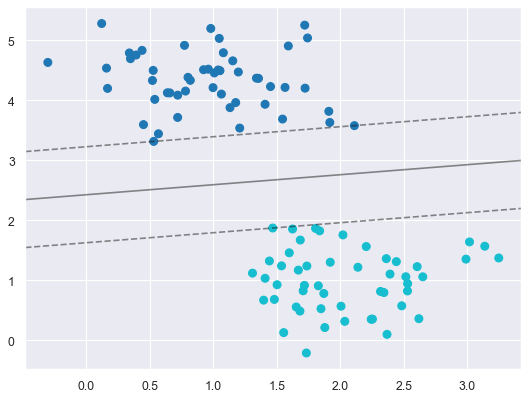

In [7]:
plt.figure(figsize=(8, 6), dpi=80)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='tab10')
plot_svc_decision_function(model);

In [8]:
model.support_vectors_

array([[0.5323772 , 3.31338909],
       [2.11114739, 3.57660449],
       [1.46870582, 1.86947425]])

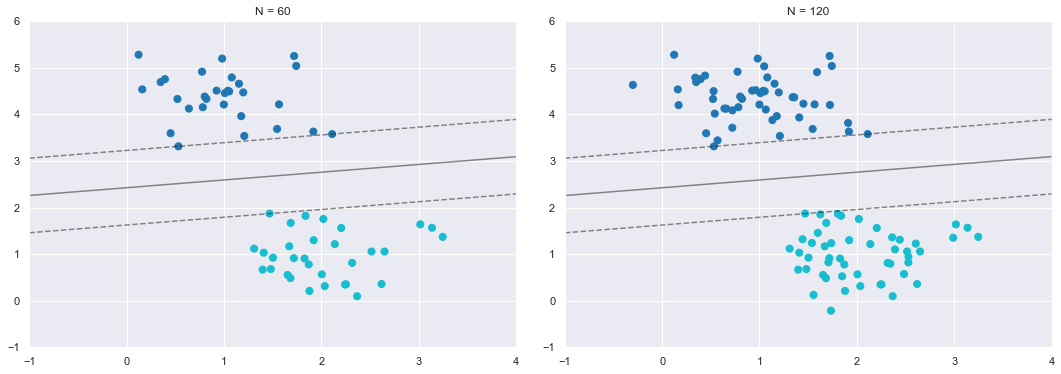

In [9]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.50)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='tab10')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

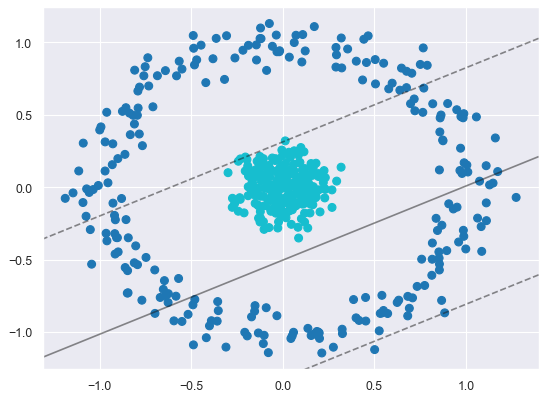

In [10]:
from sklearn.datasets import make_circles
X, y = make_circles(500, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.figure(figsize=(8, 6), dpi=80)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='tab10')
plot_svc_decision_function(clf, plot_support=True);

In [11]:
r = np.exp(-(X ** 2).sum(1))

Text(0.5, 0, 'r')

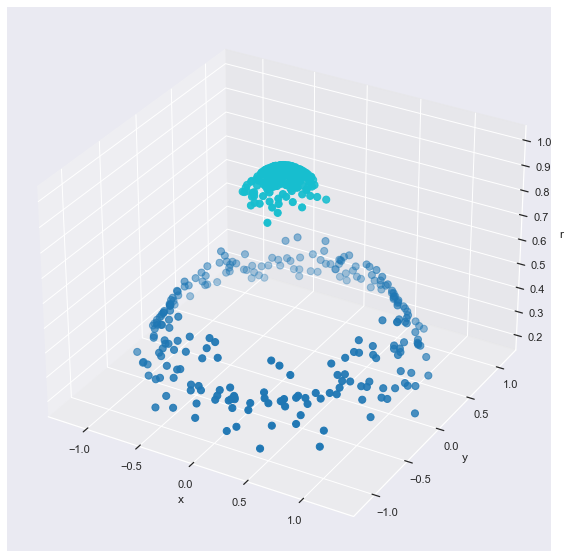

In [12]:
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(20, 10))
ax = fig.gca(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='tab10')
ax.view_init(elev=None, azim=None)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r')
